In [36]:
import pandas as pd 
import numpy as np

In [37]:
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.concat.csv', sep=';')
pd.read_csv ('funcionarios.concat.csv', sep=';')
pd.read_csv ('reservas.concat.corrigido.csv', sep=';')
pd.read_csv ('tipos_quarto.concat.csv', sep=';')
pd.read_csv ('unidades.concat.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [39]:
# 1. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
df_reservas = pd.read_csv('reservas.csv', sep=';')
df_unidades = pd.read_csv('unidades.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')
df_clientes = pd.read_csv('clientes.csv', sep=';')
df_canais = pd.read_csv('canais_venda.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.csv', sep=';')



## Corrigindo a partir daqui

## RECORRIGINDO

In [40]:
import pandas as pd


# ============================================================
# 1. VERIFICANDO A QUANTIDADE DE DIÁRIAS
# ============================================================

print("Menor qtd_diarias:", df_reservas['qtd_diarias'].min())

print(
    "Quantidade de valores negativos:",
    (df_reservas['qtd_diarias'] < 0).sum()
)

display(
    df_reservas[
        df_reservas['qtd_diarias'] < 0
    ][
        ['id_unidade', 'data_checkin', 'data_checkout', 'qtd_diarias']
    ]
)


# ============================================================
# 2. REMOVENDO AS RESERVAS COM DIÁRIAS NEGATIVAS
# ============================================================

df_reservas_analise = df_reservas[
    df_reservas['qtd_diarias'] >= 0
].copy()

print("Reservas antes:", len(df_reservas))
print("Reservas para análise:", len(df_reservas_analise))


# ============================================================
# 3. GARANTINDO QUE qtd_diarias SEJA NUMÉRICA
# ============================================================

df_reservas_analise['qtd_diarias'] = pd.to_numeric(
    df_reservas_analise['qtd_diarias'],
    errors='coerce'
)

# Remove valores que não puderam ser convertidos
df_reservas_analise = df_reservas_analise[
    df_reservas_analise['qtd_diarias'].notna()
].copy()

# Garante que a quantidade de diárias seja inteira
df_reservas_analise['qtd_diarias'] = (
    df_reservas_analise['qtd_diarias']
    .astype(int)
)


# ============================================================
# 4. GARANTINDO QUE A DATA DE CHECK-IN SEJA DATETIME
# ============================================================

df_reservas_analise['data_checkin'] = pd.to_datetime(
    df_reservas_analise['data_checkin'],
    errors='coerce'
)

# Remove reservas sem data de check-in
df_reservas_analise = df_reservas_analise[
    df_reservas_analise['data_checkin'].notna()
].copy()


# ============================================================
# 5. CRIANDO UMA LINHA PARA CADA DIÁRIA
# ============================================================

df_diarias = df_reservas_analise.loc[
    df_reservas_analise.index.repeat(
        df_reservas_analise['qtd_diarias']
    )
].copy()


# ============================================================
# 6. CRIANDO A SEQUÊNCIA DE DIAS DE CADA RESERVA
# ============================================================

dias = df_diarias.groupby(level=0).cumcount()


# ============================================================
# 7. CRIANDO A DATA DE CADA DIÁRIA
# ============================================================

df_diarias['data'] = (
    df_diarias['data_checkin'] +
    pd.to_timedelta(dias, unit='D')
)


# ============================================================
# 8. CONTANDO QUANTOS QUARTOS ESTÃO OCUPADOS
#    EM CADA UNIDADE E EM CADA DIA
# ============================================================

ocupacao_diaria = (
    df_diarias
    .groupby(['id_unidade', 'data'])
    .size()
    .reset_index(name='quartos_ocupados')
)


# ============================================================
# 9. ADICIONANDO AS INFORMAÇÕES DOS HOTÉIS
# ============================================================

ocupacao_diaria = ocupacao_diaria.merge(
    df_unidades[
        [
            'id_unidade',
            'nome_unidade',
            'num_quartos_total'
        ]
    ],
    on='id_unidade',
    how='left'
)


# ============================================================
# 10. CALCULANDO A TAXA DE OCUPAÇÃO DIÁRIA
# ============================================================

ocupacao_diaria['taxa_ocupacao'] = (
    ocupacao_diaria['quartos_ocupados'] /
    ocupacao_diaria['num_quartos_total']
) * 100


# ============================================================
# 11. IDENTIFICANDO OS DIAS ACIMA DA CAPACIDADE
# ============================================================

excesso = ocupacao_diaria[
    ocupacao_diaria['quartos_ocupados'] >
    ocupacao_diaria['num_quartos_total']
].copy()


# ============================================================
# 12. CALCULANDO QUANTOS QUARTOS EXCEDERAM A CAPACIDADE
# ============================================================

excesso['excesso_quartos'] = (
    excesso['quartos_ocupados'] -
    excesso['num_quartos_total']
)


# ============================================================
# 13. CALCULANDO O PERCENTUAL ACIMA DA CAPACIDADE
# ============================================================

excesso['percentual_acima_capacidade'] = (
    excesso['excesso_quartos'] /
    excesso['num_quartos_total']
) * 100


# ============================================================
# 14. ARREDONDANDO O PERCENTUAL
# ============================================================

excesso['percentual_acima_capacidade'] = (
    excesso['percentual_acima_capacidade']
    .round(2)
)


# ============================================================
# 15. MOSTRANDO TODOS OS DIAS ACIMA DA CAPACIDADE
# ============================================================

print("\n===== DIAS ACIMA DA CAPACIDADE =====")

display(
    excesso[
        [
            'nome_unidade',
            'data',
            'quartos_ocupados',
            'num_quartos_total',
            'excesso_quartos',
            'percentual_acima_capacidade'
        ]
    ]
    .sort_values(
        ['nome_unidade', 'data']
    )
)


# ============================================================
# 16. RESUMO POR HOTEL
# ============================================================

resumo_excesso = (
    excesso
    .groupby(
        ['id_unidade', 'nome_unidade']
    )
    .agg(
        dias_acima_capacidade=(
            'data',
            'count'
        ),

        maior_ocupacao=(
            'quartos_ocupados',
            'max'
        ),

        capacidade=(
            'num_quartos_total',
            'first'
        ),

        maior_excesso=(
            'excesso_quartos',
            'max'
        ),

        maior_percentual_acima=(
            'percentual_acima_capacidade',
            'max'
        )
    )
    .reset_index()
    .sort_values(
        'dias_acima_capacidade',
        ascending=False
    )
)


# ============================================================
# 17. MOSTRANDO O RESUMO
# ============================================================

print("\n===== RESUMO POR HOTEL =====")

display(resumo_excesso)


# ============================================================
# 18. VERIFICANDO SE EXISTE ALGUM HOTEL ACIMA DA CAPACIDADE
# ============================================================

if excesso.empty:

    print(
        "\nNenhuma unidade apresentou ocupação acima "
        "da capacidade registrada."
    )

else:

    print(
        f"\nForam encontrados {len(excesso)} "
        "dias com ocupação acima da capacidade."
    )

    print(
        f"{excesso['id_unidade'].nunique()} "
        "unidades apresentaram pelo menos um dia "
        "acima da capacidade."
    )

Menor qtd_diarias: -1
Quantidade de valores negativos: 4


,id_unidade,data_checkin,data_checkout,qtd_diarias
954,7,2023-12-07,2023-07-16,-1
1133,5,2023-08-07,2023-11-07,-1
1447,8,2024-01-11,2024-07-11,-1
2383,5,2024-01-10,2024-03-10,-1


Reservas antes: 2457
Reservas para análise: 2453

===== DIAS ACIMA DA CAPACIDADE =====


,nome_unidade,data,quartos_ocupados,num_quartos_total,excesso_quartos,percentual_acima_capacidade
961,NaraHoteis Centro,2023-07-15,74,60,14,23.33
962,NaraHoteis Centro,2023-07-16,75,60,15,25.00
1012,NaraHoteis Centro,2024-01-15,80,60,20,33.33
1013,NaraHoteis Centro,2024-01-16,80,60,20,33.33
1642,NaraHoteis Nova Iguaçu Centro,2023-10-15,61,50,11,22.00
1643,NaraHoteis Nova Iguaçu Centro,2023-10-16,61,50,11,22.00
1694,NaraHoteis Nova Iguaçu Centro,2024-06-15,64,50,14,28.00
1695,NaraHoteis Nova Iguaçu Centro,2024-06-16,64,50,14,28.00



===== RESUMO POR HOTEL =====


,id_unidade,nome_unidade,dias_acima_capacidade,maior_ocupacao,capacidade,maior_excesso,maior_percentual_acima
0,3,NaraHoteis Centro,4,80,60,20,33.33
1,5,NaraHoteis Nova Iguaçu Centro,4,64,50,14,28.00



Foram encontrados 8 dias com ocupação acima da capacidade.
2 unidades apresentaram pelo menos um dia acima da capacidade.


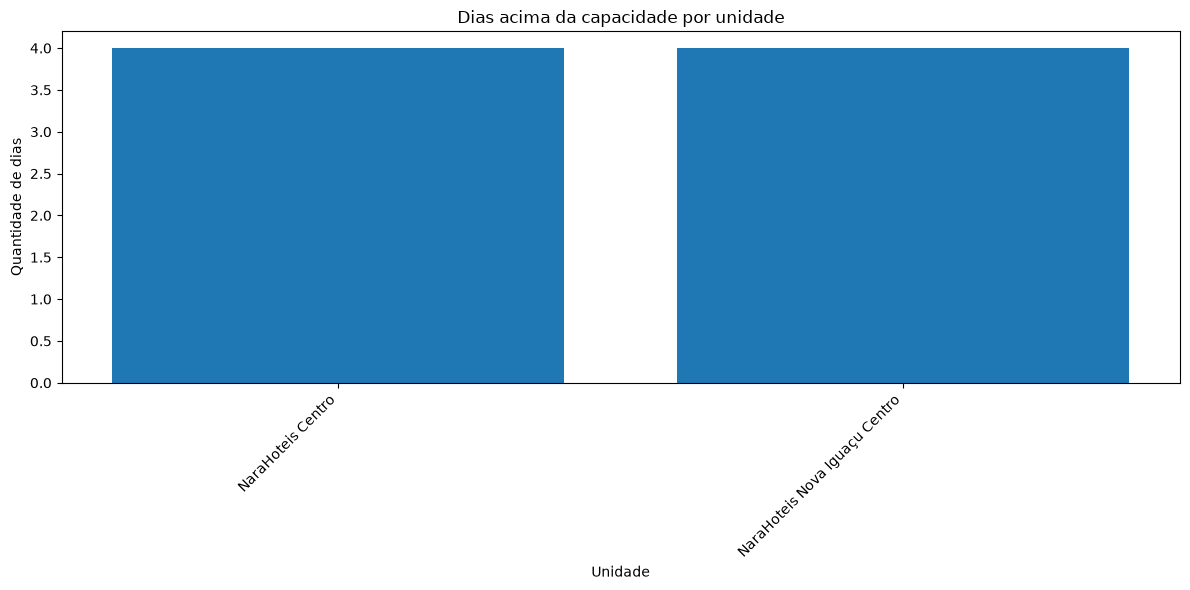

In [41]:
import matplotlib.pyplot as plt


# ============================================================
# GRÁFICO 1 - DIAS ACIMA DA CAPACIDADE POR HOTEL
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    resumo_excesso['nome_unidade'],
    resumo_excesso['dias_acima_capacidade']
)

plt.title('Dias acima da capacidade por unidade')
plt.xlabel('Unidade')
plt.ylabel('Quantidade de dias')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

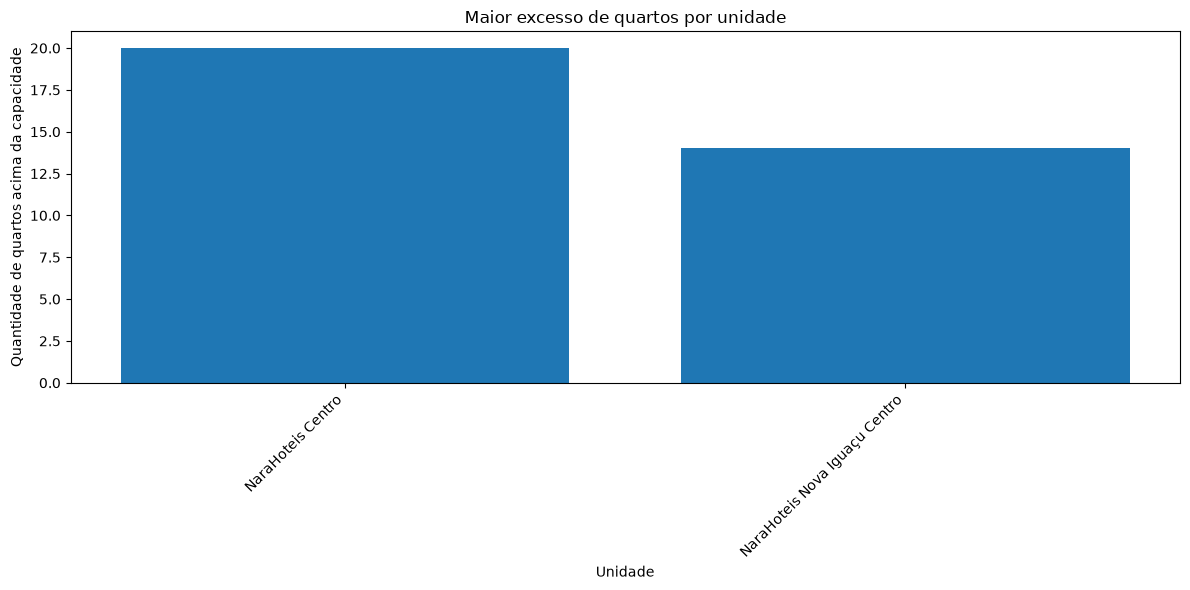

In [42]:
# ============================================================
# GRÁFICO 2 - MAIOR EXCESSO DE QUARTOS
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    resumo_excesso['nome_unidade'],
    resumo_excesso['maior_excesso']
)

plt.title('Maior excesso de quartos por unidade')
plt.xlabel('Unidade')
plt.ylabel('Quantidade de quartos acima da capacidade')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

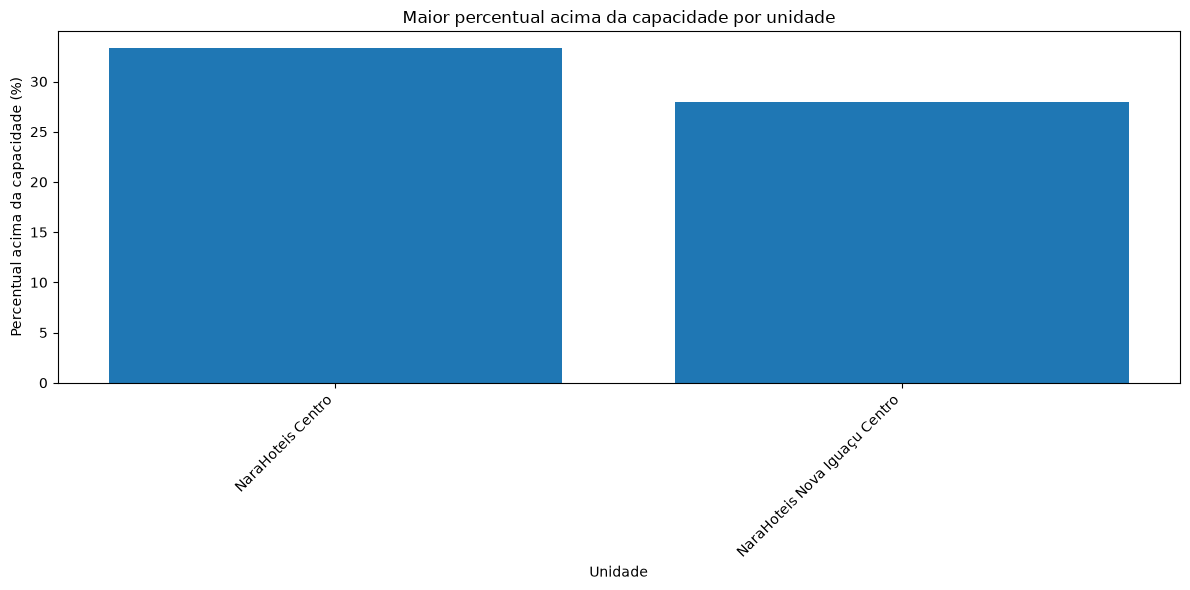

In [43]:
# ============================================================
# GRÁFICO 3 - MAIOR PERCENTUAL ACIMA DA CAPACIDADE
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    resumo_excesso['nome_unidade'],
    resumo_excesso['maior_percentual_acima']
)

plt.title('Maior percentual acima da capacidade por unidade')
plt.xlabel('Unidade')
plt.ylabel('Percentual acima da capacidade (%)')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

In [44]:
ocupacao_diaria

,id_unidade,data,quartos_ocupados,nome_unidade,num_quartos_total,taxa_ocupacao
0,1,2023-01-04,2,NaraHoteis Ipanema,80,2.50
1,1,2023-01-05,1,NaraHoteis Ipanema,80,1.25
2,1,2023-01-09,1,NaraHoteis Ipanema,80,1.25
3,1,2023-01-10,1,NaraHoteis Ipanema,80,1.25
4,1,2023-01-11,1,NaraHoteis Ipanema,80,1.25
...,...,...,...,...,...,...
5117,12,2024-12-20,2,NaraHoteis Mangaratiba,50,4.00
5118,12,2024-12-21,1,NaraHoteis Mangaratiba,50,2.00
5119,12,2024-12-22,1,NaraHoteis Mangaratiba,50,2.00
5120,12,2024-12-23,1,NaraHoteis Mangaratiba,50,2.00


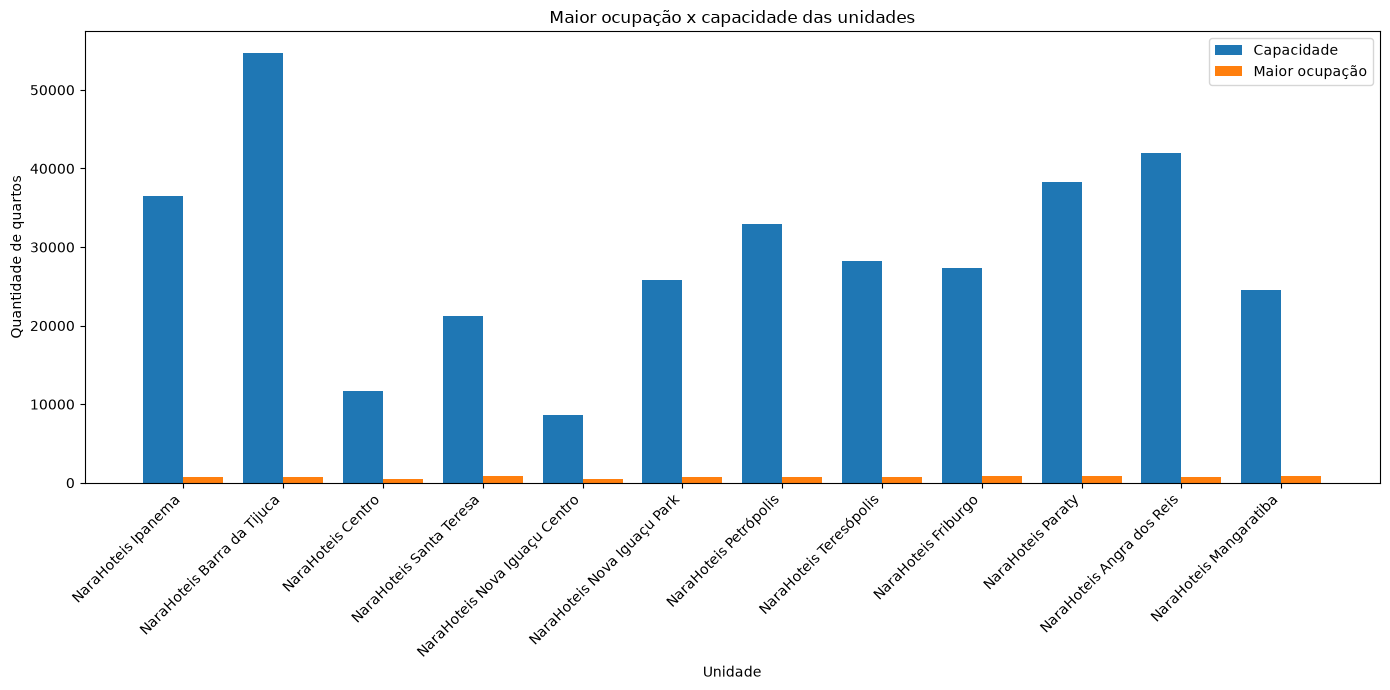

In [45]:
import matplotlib.pyplot as plt


# ============================================================
# GRÁFICO - MAIOR OCUPAÇÃO X CAPACIDADE
# ============================================================

# Pegando a maior ocupação de cada unidade
maior_ocupacao = (
    ocupacao_diaria
    .groupby(['id_unidade', 'nome_unidade'])
    .agg(
        maior_ocupacao=('quartos_ocupados', 'sum'),
        capacidade=('num_quartos_total', 'sum')
    )
    .reset_index()
)

# Criando o gráfico
plt.figure(figsize=(14, 7))

x = range(len(maior_ocupacao))

plt.bar(
    [i - 0.2 for i in x],
    maior_ocupacao['capacidade'],
    width=0.4,
    label='Capacidade'
)

plt.bar(
    [i + 0.2 for i in x],
    maior_ocupacao['maior_ocupacao'],
    width=0.4,
    label='Maior ocupação'
)

plt.title('Maior ocupação x capacidade das unidades')
plt.xlabel('Unidade')
plt.ylabel('Quantidade de quartos')

plt.xticks(
    x,
    maior_ocupacao['nome_unidade'],
    rotation=45,
    ha='right'
)

plt.legend()

plt.tight_layout()
plt.show()

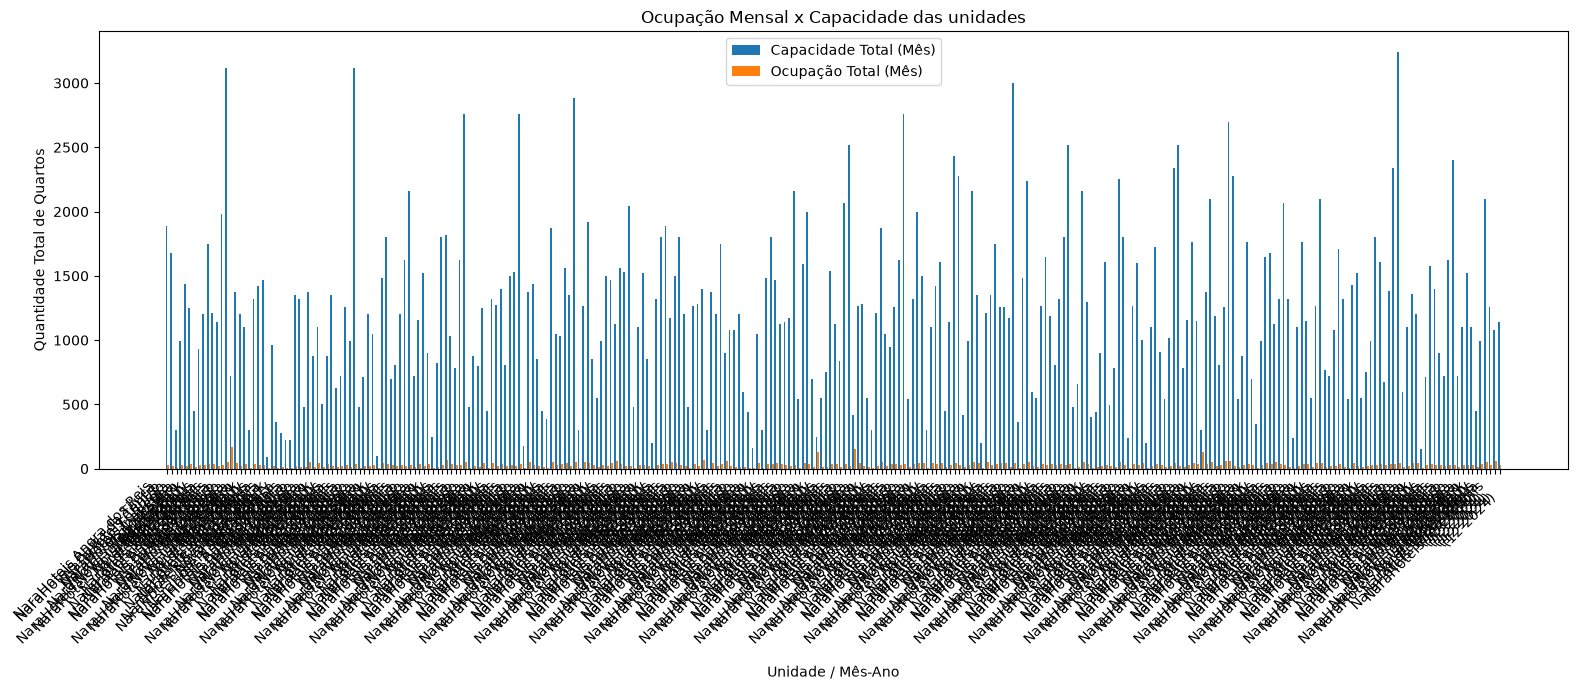

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICO - OCUPAÇÃO TOTAL X CAPACIDADE (MENSAL)
# ============================================================

# 1. Criando a regra para trazer Mês e Ano
# (Ajuste 'data' para o nome exato da sua coluna de data no DataFrame)
ocupacao_diaria['data'] = pd.to_datetime(ocupacao_diaria['data'], errors='coerce')
ocupacao_diaria['mes_ano'] = ocupacao_diaria['data'].dt.strftime('%m-%Y')

# 2. Aplicando a nova lógica no agrupamento (substituindo id_unidade e usando sum)
maior_ocupacao = (
    ocupacao_diaria
    .groupby(['mes_ano', 'nome_unidade'])
    .agg(
        maior_ocupacao=('quartos_ocupados', 'sum'),
        capacidade=('num_quartos_total', 'sum')
    )
    .reset_index()
)

# 3. Criando o gráfico
plt.figure(figsize=(16, 7))

x = range(len(maior_ocupacao))

plt.bar(
    [i - 0.2 for i in x],
    maior_ocupacao['capacidade'],
    width=0.4,
    label='Capacidade Total (Mês)'
)

plt.bar(
    [i + 0.2 for i in x],
    maior_ocupacao['maior_ocupacao'],
    width=0.4,
    label='Ocupação Total (Mês)'
)

plt.title('Ocupação Mensal x Capacidade das unidades')
plt.xlabel('Unidade / Mês-Ano')
plt.ylabel('Quantidade Total de Quartos')

# Criando rótulos que juntam o nome da unidade e o mês/ano para o eixo X
rotulos_x = maior_ocupacao['nome_unidade'] + '\n(' + maior_ocupacao['mes_ano'] + ')'

plt.xticks(
    x,
    rotulos_x,
    rotation=45,
    ha='right'
)

plt.legend()
plt.tight_layout()
plt.show()

C:\Users\robert.torres\AppData\Local\Temp\ipykernel_19820\3255351836.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pico_ocupacao, x='nome_unidade', y='ocupacao_pct', palette='coolwarm')


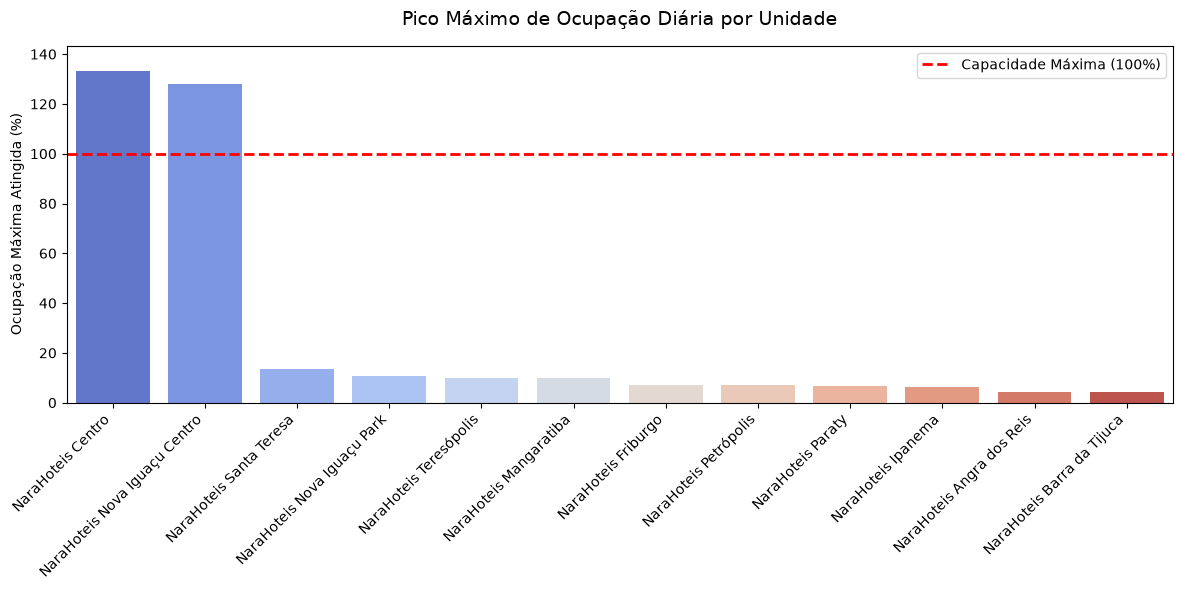

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculando o percentual de ocupação para CADA dia
# (Assumindo que 'ocupacao_diaria' já tem as colunas 'quartos_ocupados' e 'num_quartos_total')
ocupacao_diaria['ocupacao_pct'] = (ocupacao_diaria['quartos_ocupados'] / ocupacao_diaria['num_quartos_total']) * 100

# 2. Isolando o maior pico de lotação que a unidade já registrou
pico_ocupacao = ocupacao_diaria.groupby('nome_unidade')['ocupacao_pct'].max().reset_index()
pico_ocupacao = pico_ocupacao.sort_values('ocupacao_pct', ascending=False)

# 3. Visualização Executiva
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=pico_ocupacao, x='nome_unidade', y='ocupacao_pct', palette='coolwarm')

# Adicionando a linha de alerta para 100% da capacidade
plt.axhline(100, color='red', linestyle='--', linewidth=2, label='Capacidade Máxima (100%)')

plt.title('Pico Máximo de Ocupação Diária por Unidade', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('Ocupação Máxima Atingida (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(110, pico_ocupacao['ocupacao_pct'].max() + 10)) # Ajusta o teto dinamicamente
plt.legend()
plt.tight_layout()
plt.show()